In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [24]:
from sklearn.datasets import make_regression
X,y=make_regression(n_samples=4,n_features=1,n_targets=1,n_informative=1,noise=80,random_state=13)

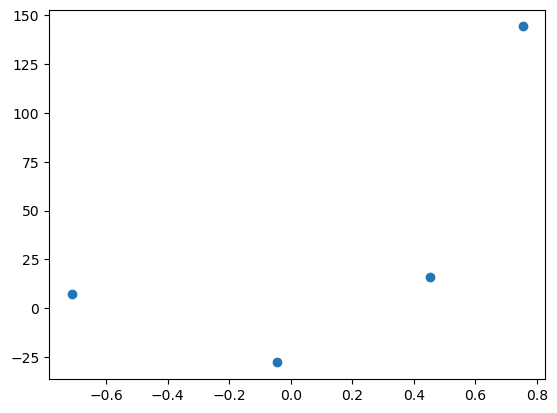

In [25]:
plt.scatter(X,y)

In [26]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
print("Coefficients :",lr.coef_)
print("Intercept :",lr.intercept_)

Coefficients : [78.35063668]
Intercept : 26.15963284313262


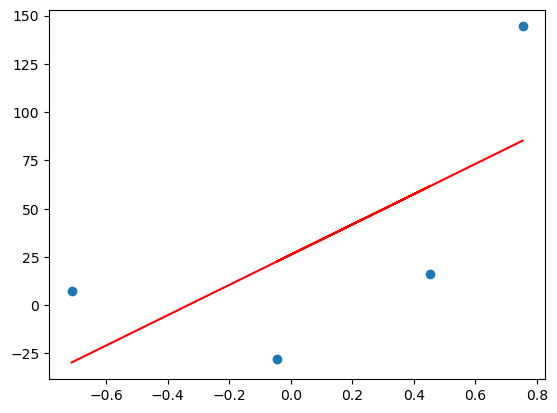

In [28]:
plt.scatter(X,y)
plt.plot(X,lr.predict(X),color='red')

In [29]:
# Lets apply Gradient Descent assuming slope is constant m = 78.35
# and let's assume the starting value for intercept b = 0
y_pred=((78.35)*X)+(0)

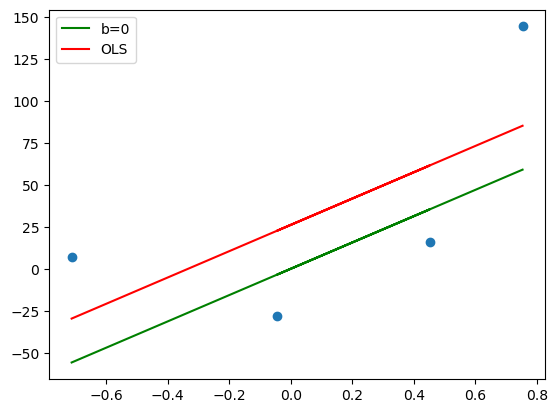

In [30]:
plt.scatter(X,y)
plt.plot(X,y_pred,color='green',label="b=0")
plt.plot(X,lr.predict(X),color='red',label="OLS")
plt.legend()
plt.show()

In [31]:
# calculating slope at b=0 m is fixed
m=78.35
b=0
loss_slope=-2*(np.sum(y-m*X.ravel()-b)) # why X.ravel()=> because X shape is (4,1) but we want (4,) other wise numpy will broadcast y to (4,1)
print(loss_slope)

-209.27763408209216


In [32]:
learning_rate=0.1
step_size=learning_rate*loss_slope
print(step_size)
b=b-step_size
print(b)



-20.927763408209216
20.927763408209216


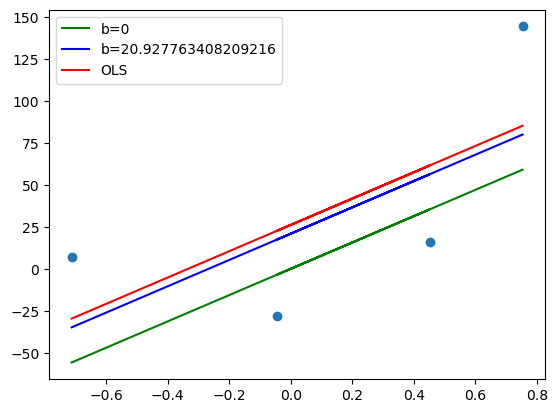

In [33]:
y_pred1=m*X+b

plt.scatter(X,y)
plt.plot(X,y_pred,color='green',label="b=0")
plt.plot(X,y_pred1,color='blue',label="b={}".format(b))
plt.plot(X,lr.predict(X),color='red',label="OLS")
plt.legend()
plt.show()

In [34]:
def gradient_descent(X,y,learning_rate,iterations,b):
    m=78.35
    for i in range(iterations):
        y_pred=m*X+b
        slope=-2*(np.sum(y-m*X.ravel()-b))
        step_size=learning_rate*slope
        b=b-step_size
        print(f"b value after {i} iterations is {b}")
    return b

In [35]:
gradient_descent(X,y,0.1,10,0)

b value after 0 iterations is 20.927763408209216
b value after 1 iterations is 25.11331608985106
b value after 2 iterations is 25.95042662617943
b value after 3 iterations is 26.1178487334451
b value after 4 iterations is 26.151333154898236
b value after 5 iterations is 26.158030039188862
b value after 6 iterations is 26.15936941604699
b value after 7 iterations is 26.159637291418615
b value after 8 iterations is 26.15969086649294
b value after 9 iterations is 26.159701581507804


np.float64(26.159701581507804)

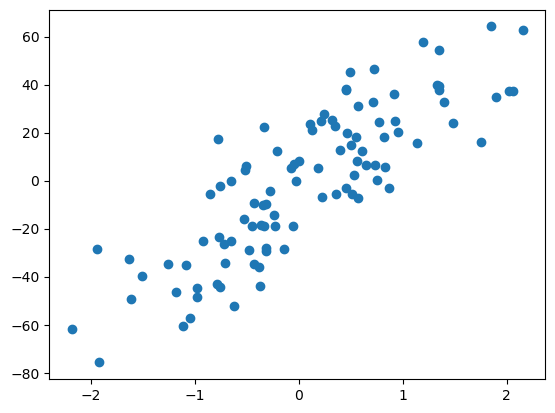

In [36]:
from sklearn.datasets import make_regression
X,y=make_regression(n_samples=100,n_features=1,n_targets=1,n_informative=1,noise=20,random_state=13)
plt.scatter(X,y)
plt.show()

In [37]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [38]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)
print(lr.coef_)
print(lr.intercept_)

[28.16404017]
-2.7130725669241036


In [39]:
y_pred = lr.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.6186926408914154

### Simple Linear Regression using Gradient Descent when m is fixed

In [40]:
# m is fixed and b is dynamic
class GradientDescent:
    def __init__(self,learning_rate,epoch):
        self.b=0
        self.m=28.16
        self.learning_rate=learning_rate
        self.epoch=epoch

    def fit(self,X,y):
        for i in range(self.epoch):
            slope=-2*(np.sum(y-self.m*X.ravel()-self.b))
            step_size=self.learning_rate*slope
            self.b= self.b-step_size
            print(f"b value after {i} iterations is {self.b}")

    def predict(self,X):
        return self.m*X+self.b

In [41]:
gd=GradientDescent(0.01,20)

In [42]:
gd.fit(X_train,y_train)

b value after 0 iterations is -4.340758540593186
b value after 1 iterations is -1.736303416237274
b value after 2 iterations is -3.2989764908508223
b value after 3 iterations is -2.361372646082692
b value after 4 iterations is -2.9239349529435703
b value after 5 iterations is -2.5863975688270435
b value after 6 iterations is -2.7889199992969607
b value after 7 iterations is -2.6674065410150085
b value after 8 iterations is -2.7403146159841807
b value after 9 iterations is -2.6965697710026775
b value after 10 iterations is -2.7228166779915792
b value after 11 iterations is -2.707068533798238
b value after 12 iterations is -2.7165174203142426
b value after 13 iterations is -2.7108480884046395
b value after 14 iterations is -2.714249687550403
b value after 15 iterations is -2.7122087280629437
b value after 16 iterations is -2.7134333037554192
b value after 17 iterations is -2.712698558339934
b value after 18 iterations is -2.7131394055892253
b value after 19 iterations is -2.7128748972396

### Simple Linear Regression using Gradient Descent when both m and b are dynamic

In [43]:
# both m and b are dynamic
class GradientDescent:
    def __init__(self,m=0,b=0,learning_rate=0.01,epoch=20):
        self.b=b
        self.m=m
        self.learning_rate=learning_rate
        self.epoch=epoch

    def fit(self,X,y):
        for i in range(self.epoch):
            b_slope=-2*np.sum(y-self.m*X.ravel()-self.b)
            b_step_size=self.learning_rate*b_slope
            self.b= self.b-b_step_size
            m_slope=-2*np.sum((y-self.m*X.ravel()-self.b)*X.ravel())
            m_step_size=self.learning_rate*m_slope
            self.m=self.m-m_step_size   
            #print(f"b value after {i} iterations is {self.b} and m value after {i} iterations is {self.m}")
            

    def predict(self,X):
        return self.m*X+self.b

In [44]:
gd=GradientDescent(0,0,0.001,100)
gd.fit(X_train,y_train)
from sklearn.metrics import r2_score
r2_score(y_test,gd.predict(X_test))

0.6186926734232057